In [1]:
library(ggplot2)
library(ggrepel)
library(reshape2)

In [2]:
library(readr)


In [3]:
exps <- read.csv('/home/dg204/projects/rsignatures/src/sv_overlap_config.csv', header=FALSE, fill = TRUE,
  col.names = c('V1', 'V2', 'V3'))
#exps <- read_csv('/home/dg204/projects/rsignatures/src/sv_overlap_config.csv', col_names = FALSE)
#exps <- subset(exps, !grepl('_', V1) | (V1=='RS3_short'))
#exps <- subset(exps, !grepl('_', V1) | (V1=='RS3_short') | (V1=='ccne1_dups')| (V1=='cdk12_dups') | (V1=='cdk12_R1_dups') | (V1=='ccne1_R1_dups'))

In [4]:
exps

V1,V2,V3
<chr>,<chr>,<chr>
RS1,max.Ref.Sig=='Ref.Sig.R1' & (is.clustered==FALSE),
RS3,max.Ref.Sig=='Ref.Sig.R3' & (is.clustered==FALSE),
RS5,max.Ref.Sig=='Ref.Sig.R5' & (is.clustered==FALSE),
RS7,max.Ref.Sig=='Ref.Sig.R7' & (is.clustered==FALSE),
RS8,max.Ref.Sig=='Ref.Sig.R8' & (is.clustered==FALSE),
RS9,max.Ref.Sig=='Ref.Sig.R9' & (is.clustered==FALSE),
RS10,max.Ref.Sig=='Ref.Sig.R10' & (is.clustered==FALSE),
RS11,max.Ref.Sig=='Ref.Sig.R11' & (is.clustered==FALSE),
RS14,max.Ref.Sig=='Ref.Sig.R14' & (is.clustered==FALSE),


In [5]:
result.list <- list()

features <- NULL
for (ri in 1:nrow(exps)) {
#for (ri in 1:5) {
    print(ri)
    exp.name <- exps$V1[ri]
    print(exps$V3[ri])
    if (exps$V3[ri]=='shuffleSimple') {
        exp.name <- paste0(exp.name, '_shuffle_simple')
    } else if (exps$V3[ri]=='shuffleFlip') {
        exp.name <- paste0(exp.name, '_shuffle_flip')
    }
    fn <- paste0('/home/dg204/park_dglodzik/svig/', exp.name, '/','stats_light_',exp.name,'.RData')
    if (file.exists(fn)) {
        load(fn)
        resultList$exp.name <- exp.name
        resultList[['ovl_r']] <- NULL
        resultList[['expression_profile_low']] <- NULL
        resultList[['expression_profile_high']] <- NULL
        resultList[['cvg']] <- NULL
        resultList[['measure']] <- NULL
        resultList[['repliseq_o.df']] <- NULL
        resultList[['expression_profile_high']] <- NULL
        resultList[['expression_profile_low']] <- NULL
        resultList[['segments.gr']] <- NULL
        
        result.list[[exp.name]] <- resultList
        print(paste(exp.name, 'loaded'))
        print(fn)
    } else {
        print(paste(exp.name, ' not loaded'))
        print(fn)
    }

}

[1] 1
[1] ""
[1] "RS1 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS1/stats_light_RS1.RData"
[1] 2
[1] ""
[1] "RS3 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS3/stats_light_RS3.RData"
[1] 3
[1] ""
[1] "RS5 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS5/stats_light_RS5.RData"
[1] 4
[1] ""
[1] "RS7 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS7/stats_light_RS7.RData"
[1] 5
[1] ""
[1] "RS8 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS8/stats_light_RS8.RData"
[1] 6
[1] ""
[1] "RS9 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS9/stats_light_RS9.RData"
[1] 7
[1] ""
[1] "RS10 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS10/stats_light_RS10.RData"
[1] 8
[1] ""
[1] "RS11 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS11/stats_light_RS11.RData"
[1] 9
[1] ""
[1] "RS14 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS14/stats_light_RS14.RData"
[1] 10
[1] ""
[1] "RS15 loaded"
[1] "/home/dg204/park_dglodzik/svig/RS15/stats_light_RS15.RData"
[1] 11
[1] ""
[1] "cdk12_dups loaded"
[1] "/home/dg204/pa

In [6]:
#sapply(result.list, names, simplify=FALSE)

In [7]:
## Align a list of named lists into a rectangular data.frame
## - columns = union of all field names
## - missing fields filled with NA
## - non-scalar values serialized to JSON strings so write.csv works

# install.packages("jsonlite") if needed
library(jsonlite)

# 1) union of all keys across elements
all_keys <- unique(unlist(lapply(result.list, names)))

# 2) helper to turn any value into a single scalar string or atomic
scalarize <- function(v) {
  if (length(v) == 0) return(NA)                 # empty -> NA
  if (length(v) == 1 && is.atomic(v)) return(v)  # simple scalar -> keep
  if (is.atomic(v)) return(paste(v, collapse = ";"))  # vector -> "a;b;c"
  # complex/list -> JSON
  jsonlite::toJSON(v, auto_unbox = TRUE, null = "null")
}

# 3) build one-row data.frame per element, aligned to all_keys
row_from <- function(x) {
  z <- setNames(vector("list", length(all_keys)), all_keys)
  # fill present fields
  for (nm in names(x)) z[[nm]] <- scalarize(x[[nm]])
  # fill missing as NA
  missing <- setdiff(all_keys, names(x))
  for (nm in missing) z[[nm]] <- NA
  as.data.frame(z, check.names = FALSE, stringsAsFactors = FALSE)
}

# 4) bind rows
result.df <- do.call(rbind, lapply(result.list, row_from))
rownames(result.df) <- names(result.list)  # optional

# 5) write CSV
write.csv(
  result.df,
  file = "~/projects/rsignatures/data/processed/svs/origin.enrichment.per.signature.oct16th.csv",
  row.names = FALSE,
  quote = TRUE
)

In [8]:
subset(result.df, 	exp.name=='RS6b')

,originEnrichmentES,originEnrichmentP,originEnrichmentES_lower95,originEnrichmentES_higher95,minBin,repliseq_midpoint_bp1_wilcoxonP,repliseq_midpoint_bp1_mean_diff,repliseq_midpoint_bp2_wilcoxonP,repliseq_midpoint_bp2_mean_diff,repliseq_midpoint_both_bp2s_wilcoxonP,⋯,gene_strand_sv_lower,gene_strand_sv_higher,median_length,repeatOverlapBpProp,repeatOverlapCoincidence,repeatL1FisherEstimate,repeatL1FisherEstimate_lower,repeatL1FisherEstimate_higher,repeatL1FisherPvalue,exp.name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
RS6b,0.9197755,0,0.9169749,0.9225846,447,0.03539956,-0.4318405,0.4943316,-0.2517485,0.1074643,⋯,0.9729786,0.9895352,1100.664,0.4997135,0.2459987,1.479542,1.353272,1.616386,1.450668e-17,RS6b


In [9]:
#result.df <- data.frame(do.call('rbind', result.list))

#result.df <- data.frame(lapply(result.df, function(x) {
#  if (is.list(x)) sapply(x, toString) else x
#}), stringsAsFactors = FALSE)

# Now write to CSV
#write.csv(result.df, file = "~/projects/rsignatures/data/processed/svs/origin.enrichment.per.signature.aug25.csv", row.names = FALSE, quote=TRUE)


In [18]:
result.df

,originEnrichmentES,originEnrichmentP,originEnrichmentES_lower95,originEnrichmentES_higher95,minBin,repliseq_midpoint_bp1_wilcoxonP,repliseq_midpoint_bp1_mean_diff,repliseq_midpoint_bp2_wilcoxonP,repliseq_midpoint_bp2_mean_diff,repliseq_midpoint_both_bp2s_wilcoxonP,⋯,median_length,repeatOverlapBpProp,repeatOverlapCoincidence,repeatL1FisherEstimate,repeatL1FisherEstimate_lower,repeatL1FisherEstimate_higher,repeatL1FisherPvalue,exp.name,originEnrichmentPmlog,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
RS1,1.2367980,1.000000e-16,1.2296135,1.2440245,446,1.057534e-02,0.4682728241,8.262276e-04,5.557390e-01,6.679610e-04,⋯,135.8020,0.5042904,0.2887892,1.6027254,1.4590716,1.759032,3.367240e-22,RS1,1.600000e+01,RS1
RS3,1.3170471,1.000000e-16,1.2950139,1.3394553,443,9.074324e-03,-0.1507068528,2.333946e-01,-1.723526e-01,4.185030e-01,⋯,9.5720,0.4977810,0.3020603,1.9590204,1.7864292,2.146920,2.870715e-44,RS3,1.600000e+01,RS3
RS5,0.9999752,1.000000e+00,0.9845345,1.0156580,449,2.571366e-02,-0.2232256769,3.083400e-01,-1.772756e-01,6.149671e-02,⋯,9.0180,0.5170364,0.3603244,2.3752193,2.1972680,2.566455,1.479381e-99,RS5,4.788850e-12,RS5
RS7,0.9019664,1.000000e-16,0.8895924,0.9145124,449,6.332018e-01,-0.0607890361,1.330085e-01,-3.014910e-01,2.534196e-01,⋯,60.8195,0.4907013,0.3023426,1.8795305,1.6958290,2.081404,2.843969e-32,RS7,1.600000e+01,RS7
RS8,0.5998237,5.342146e-10,0.5099735,0.7055044,448,3.826193e-01,-0.0351318346,4.758352e-01,-5.692506e-02,3.602962e-01,⋯,2.2110,0.7701548,0.8066524,21.3313871,18.8839662,24.117672,0.000000e+00,RS8,9.272284e+00,RS8
RS9,1.1249781,5.106994e-03,1.0365879,1.2209054,449,9.783443e-01,-0.0226427164,9.212255e-01,1.371849e-02,9.669912e-01,⋯,2.7440,0.5218154,0.4203273,4.1070750,3.5895981,4.698290,5.830653e-91,RS9,2.291835e+00,RS9
RS10,1.0723124,4.708480e-16,1.0543961,1.0905332,432,5.995838e-01,0.1483968875,9.827649e-01,-1.283614e-01,7.533062e-01,⋯,63.4155,0.4923643,0.2766885,1.3953840,1.0006068,1.926614,3.968936e-02,RS10,1.532712e+01,RS10
RS11,0.8630653,1.000000e-16,0.8601662,0.8659742,429,2.896268e-01,-0.2973055958,8.474147e-02,-6.172257e-01,1.087148e-01,⋯,6308.0785,0.4968314,0.2134905,1.0852363,0.9542041,1.232062,2.028898e-01,RS11,1.600000e+01,RS11
RS14,1.0222977,1.744867e-04,1.0106014,1.0341293,400,5.759435e-01,0.8841234769,2.144287e-01,8.982967e-01,3.012768e-01,⋯,699.4700,0.5279275,0.2310345,1.0675586,0.7680494,1.466179,6.877648e-01,RS14,3.758238e+00,RS14


In [11]:
head(result.df)

,originEnrichmentES,originEnrichmentP,originEnrichmentES_lower95,originEnrichmentES_higher95,minBin,repliseq_midpoint_bp1_wilcoxonP,repliseq_midpoint_bp1_mean_diff,repliseq_midpoint_bp2_wilcoxonP,repliseq_midpoint_bp2_mean_diff,repliseq_midpoint_both_bp2s_wilcoxonP,⋯,gene_strand_sv_lower,gene_strand_sv_higher,median_length,repeatOverlapBpProp,repeatOverlapCoincidence,repeatL1FisherEstimate,repeatL1FisherEstimate_lower,repeatL1FisherEstimate_higher,repeatL1FisherPvalue,exp.name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
RS1,1.2367980,0.000000e+00,1.2296135,1.2440245,446,0.010575342,0.46827282,0.0008262276,0.55573902,0.000667961,⋯,0.9535168,0.9954387,135.8020,0.5042904,0.2887892,1.602725,1.459072,1.759032,3.367240e-22,RS1
RS3,1.3170471,6.003052e-226,1.2950139,1.3394553,443,0.009074324,-0.15070685,0.2333946329,-0.17235258,0.418503011,⋯,0.9579485,1.0834724,9.5720,0.4977810,0.3020603,1.959020,1.786429,2.146920,2.870715e-44,RS3
RS5,0.9999752,1.000000e+00,0.9845345,1.0156580,449,0.025713659,-0.22322568,0.3083400500,-0.17727562,0.061496715,⋯,0.9148454,1.0289099,9.0180,0.5170364,0.3603244,2.375219,2.197268,2.566455,1.479381e-99,RS5
RS7,0.9019664,1.498350e-48,0.8895924,0.9145124,449,0.633201827,-0.06078904,0.1330084548,-0.30149104,0.253419592,⋯,0.9092188,1.0115108,60.8195,0.4907013,0.3023426,1.879531,1.695829,2.081404,2.843969e-32,RS7
RS8,0.5998237,5.342146e-10,0.5099735,0.7055044,448,0.382619266,-0.03513183,0.4758352364,-0.05692506,0.360296232,⋯,0.9266677,2.9341401,2.2110,0.7701548,0.8066524,21.331387,18.883966,24.117672,0.000000e+00,RS8
RS9,1.1249781,5.106994e-03,1.0365879,1.2209054,449,0.978344325,-0.02264272,0.9212255174,0.01371849,0.966991158,⋯,0.5855190,1.1130183,2.7440,0.5218154,0.4203273,4.107075,3.589598,4.698290,5.830653e-91,RS9


In [12]:
result.df

,originEnrichmentES,originEnrichmentP,originEnrichmentES_lower95,originEnrichmentES_higher95,minBin,repliseq_midpoint_bp1_wilcoxonP,repliseq_midpoint_bp1_mean_diff,repliseq_midpoint_bp2_wilcoxonP,repliseq_midpoint_bp2_mean_diff,repliseq_midpoint_both_bp2s_wilcoxonP,⋯,gene_strand_sv_lower,gene_strand_sv_higher,median_length,repeatOverlapBpProp,repeatOverlapCoincidence,repeatL1FisherEstimate,repeatL1FisherEstimate_lower,repeatL1FisherEstimate_higher,repeatL1FisherPvalue,exp.name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
RS1,1.2367980,0.000000e+00,1.2296135,1.2440245,446,1.057534e-02,0.4682728241,8.262276e-04,5.557390e-01,6.679610e-04,⋯,0.9535168,0.9954387,135.8020,0.5042904,0.2887892,1.6027254,1.4590716,1.759032,3.367240e-22,RS1
RS3,1.3170471,6.003052e-226,1.2950139,1.3394553,443,9.074324e-03,-0.1507068528,2.333946e-01,-1.723526e-01,4.185030e-01,⋯,0.9579485,1.0834724,9.5720,0.4977810,0.3020603,1.9590204,1.7864292,2.146920,2.870715e-44,RS3
RS5,0.9999752,1.000000e+00,0.9845345,1.0156580,449,2.571366e-02,-0.2232256769,3.083400e-01,-1.772756e-01,6.149671e-02,⋯,0.9148454,1.0289099,9.0180,0.5170364,0.3603244,2.3752193,2.1972680,2.566455,1.479381e-99,RS5
RS7,0.9019664,1.498350e-48,0.8895924,0.9145124,449,6.332018e-01,-0.0607890361,1.330085e-01,-3.014910e-01,2.534196e-01,⋯,0.9092188,1.0115108,60.8195,0.4907013,0.3023426,1.8795305,1.6958290,2.081404,2.843969e-32,RS7
RS8,0.5998237,5.342146e-10,0.5099735,0.7055044,448,3.826193e-01,-0.0351318346,4.758352e-01,-5.692506e-02,3.602962e-01,⋯,0.9266677,2.9341401,2.2110,0.7701548,0.8066524,21.3313871,18.8839662,24.117672,0.000000e+00,RS8
RS9,1.1249781,5.106994e-03,1.0365879,1.2209054,449,9.783443e-01,-0.0226427164,9.212255e-01,1.371849e-02,9.669912e-01,⋯,0.5855190,1.1130183,2.7440,0.5218154,0.4203273,4.1070750,3.5895981,4.698290,5.830653e-91,RS9
RS10,1.0723124,4.708480e-16,1.0543961,1.0905332,432,5.995838e-01,0.1483968875,9.827649e-01,-1.283614e-01,7.533062e-01,⋯,0.9817722,1.1023294,63.4155,0.4923643,0.2766885,1.3953840,1.0006068,1.926614,3.968936e-02,RS10
RS11,0.8630653,0.000000e+00,0.8601662,0.8659742,429,2.896268e-01,-0.2973055958,8.474147e-02,-6.172257e-01,1.087148e-01,⋯,0.9838537,0.9960580,6308.0785,0.4968314,0.2134905,1.0852363,0.9542041,1.232062,2.028898e-01,RS11
RS14,1.0222977,1.744867e-04,1.0106014,1.0341293,400,5.759435e-01,0.8841234769,2.144287e-01,8.982967e-01,3.012768e-01,⋯,0.9354496,1.0032616,699.4700,0.5279275,0.2310345,1.0675586,0.7680494,1.466179,6.877648e-01,RS14


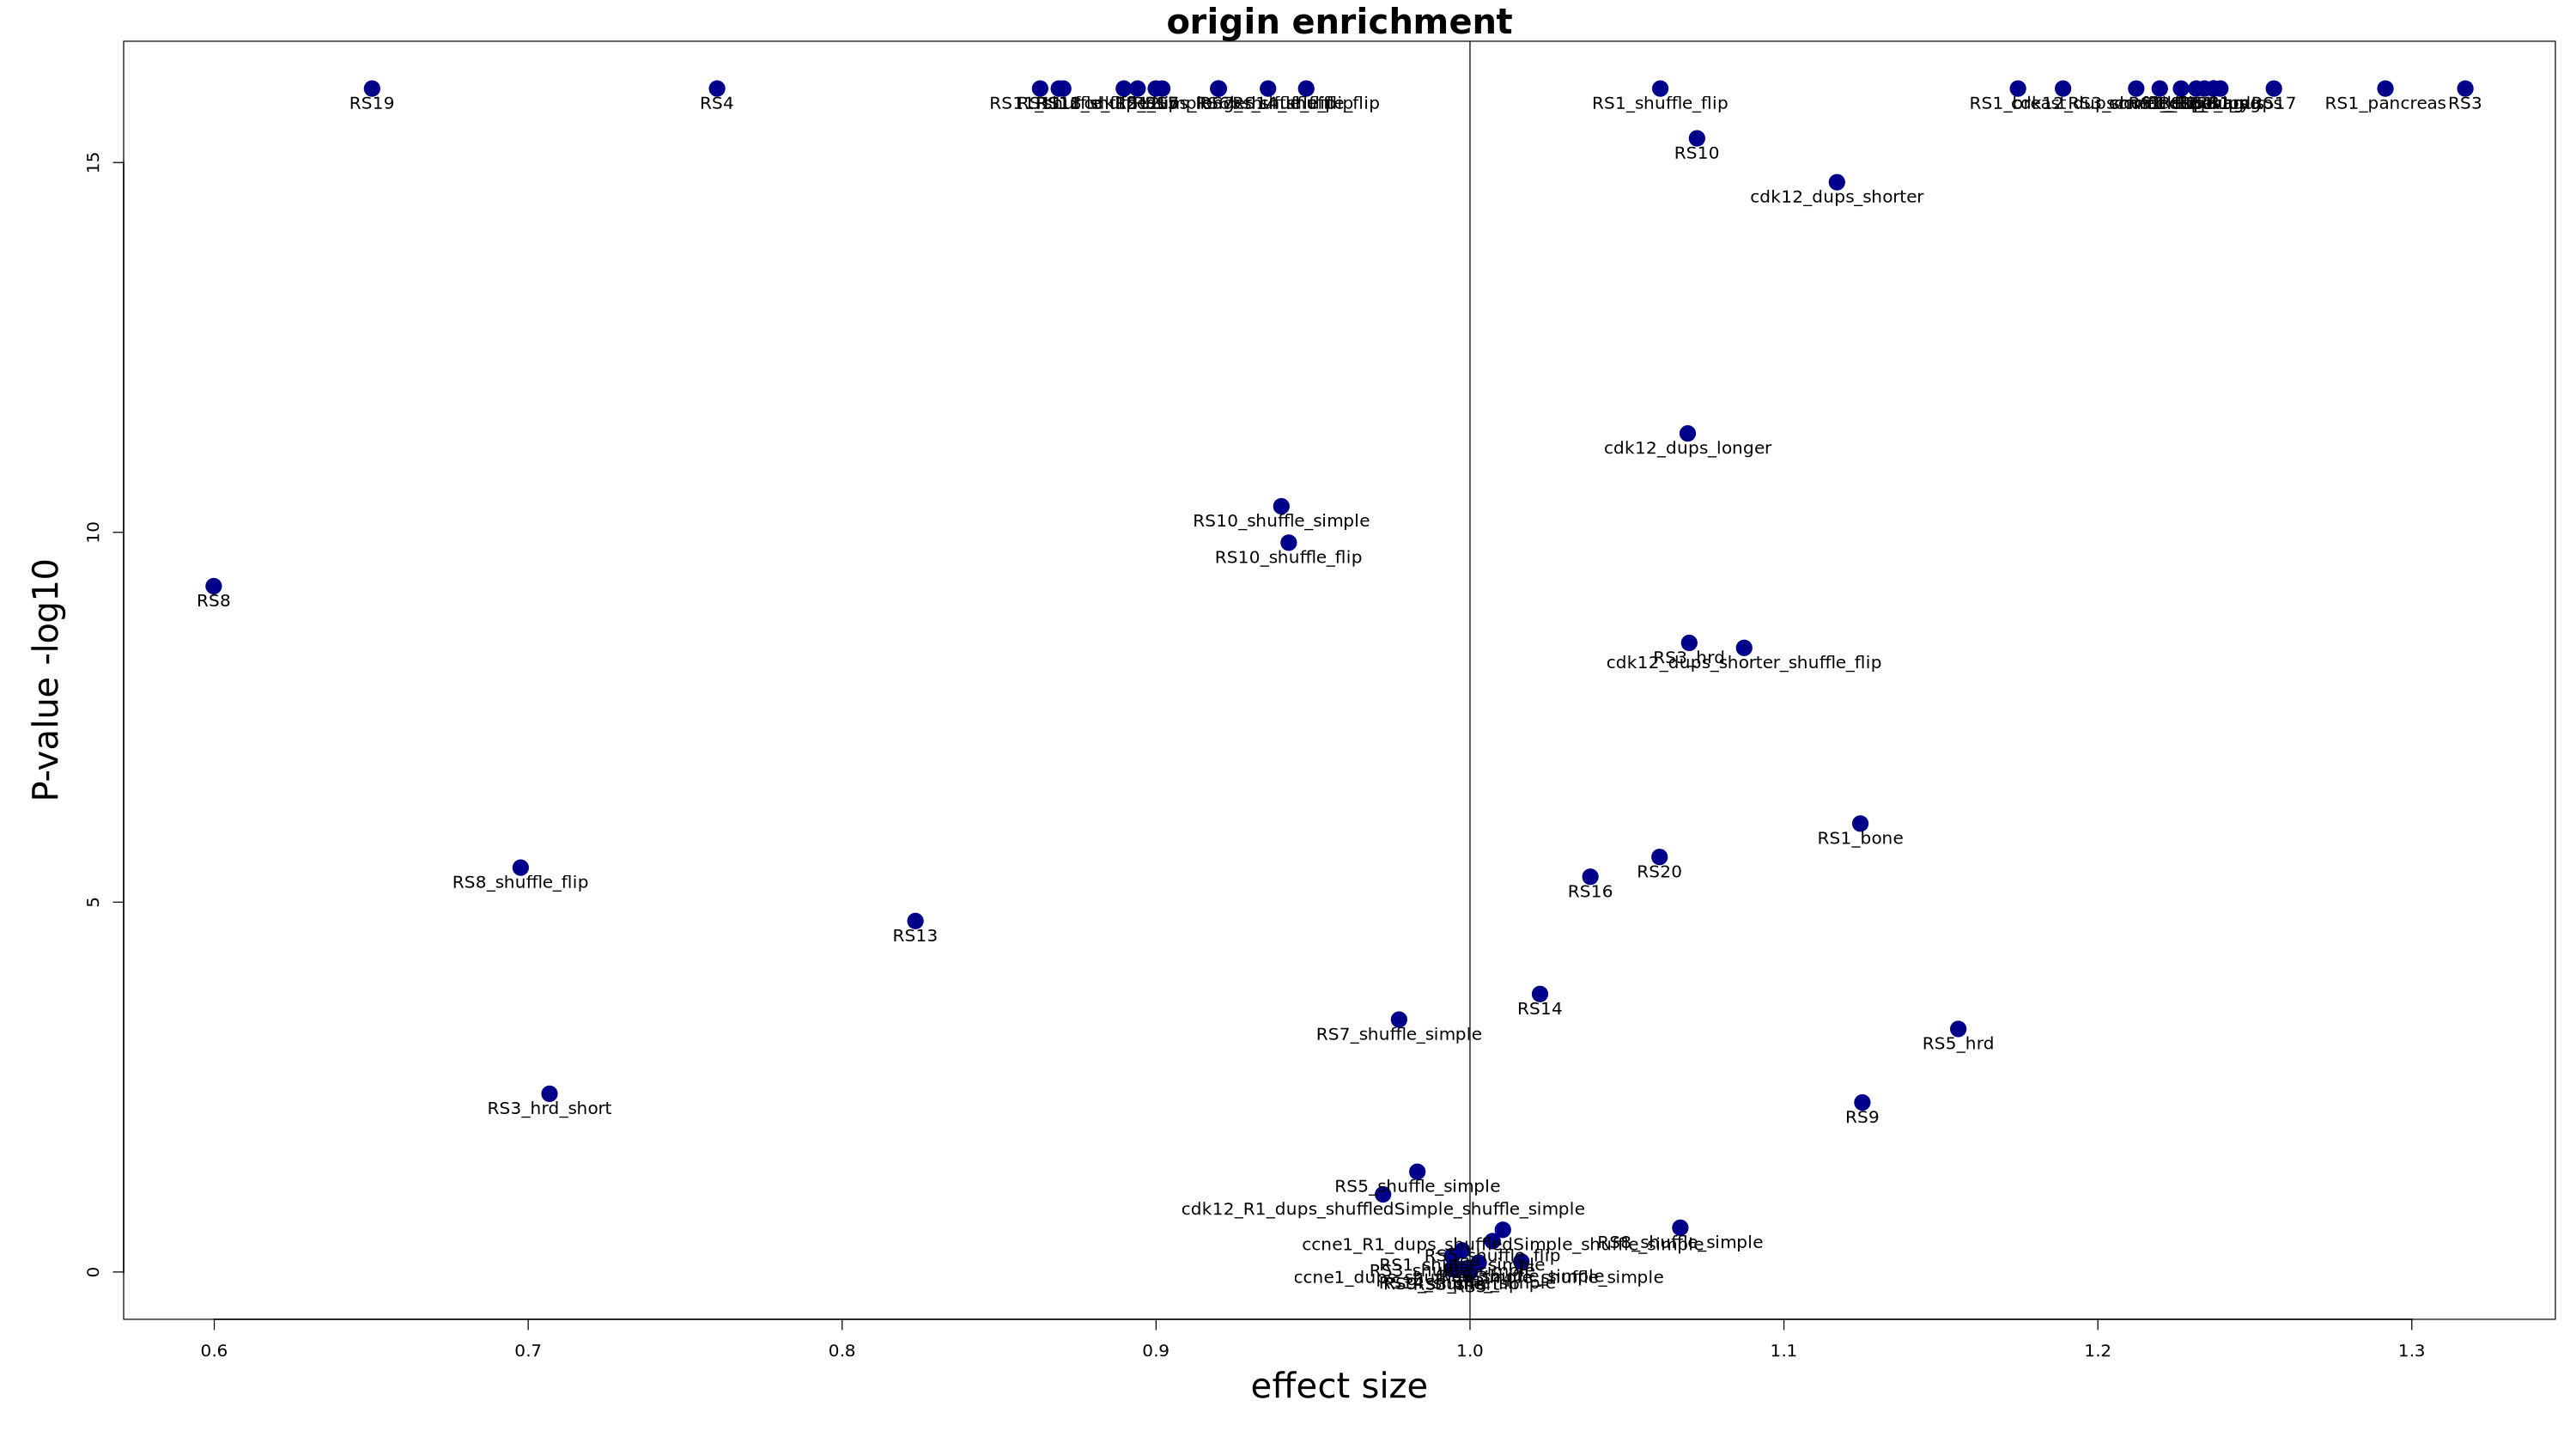

In [13]:
result.df$originEnrichmentP[result.df$originEnrichmentP<10^-16] <- 1e-16

options(repr.plot.width=25, repr.plot.height=14)
par( mar = c(6, 6, 2, 1), cex.lab = 2, cex.main = 2)


plot(result.df$originEnrichmentES, 
     -log10(as.numeric (result.df$originEnrichmentP)), pch=19, col='darkblue', cex=2, main='origin enrichment', xlab='effect size', ylab='P-value -log10')
abline(v=1)
text(result.df$originEnrichmentES, 
     -log10(as.numeric(result.df$originEnrichmentP)),
     label=rownames(result.df), pos=1)


Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


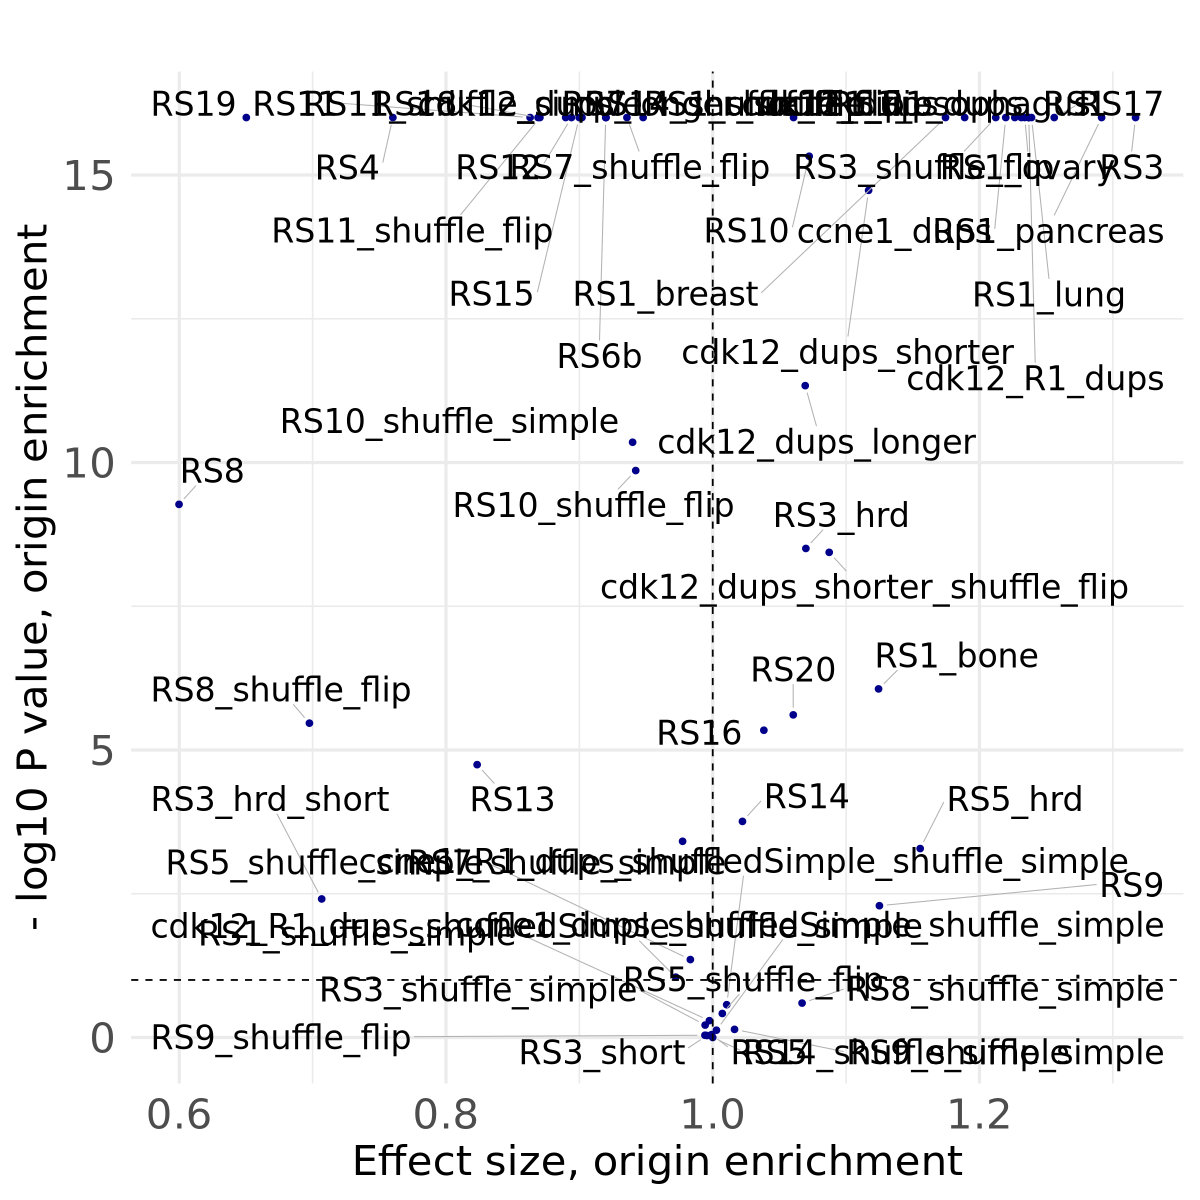

In [14]:
result.df$originEnrichmentPmlog <- -log10(as.numeric (result.df$originEnrichmentP))
result.df$label <- rownames(result.df)
result.df$originEnrichmentES <- as.numeric(as.character(result.df$originEnrichmentES))
result.df$originEnrichmentPmlog <- as.numeric(as.character(result.df$originEnrichmentPmlog))

options(repr.plot.width=10, repr.plot.height=10)

p <- ggplot(result.df, aes(x = originEnrichmentES,
                           y = originEnrichmentPmlog,
                           label = label)) +
  geom_point(color = 'darkblue') +
  geom_text_repel(
    angle = 0,
    size = 7,
    max.overlaps = 1000,
    box.padding = 0.8,
    point.padding = 0.5,
    segment.color = "grey70",
    segment.size = 0.3
  ) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  geom_hline(yintercept = 1, linetype = "dashed") +
xlab("Effect size, origin enrichment") +
  ylab("- log10 P value, origin enrichment") +
  ggtitle("") +
  theme_minimal(base_size = 20) +
  theme(
    axis.title = element_text(size = 25),   # Axis label size
    axis.text = element_text(size = 25)     # Tick label size
  )

print(p)
#ggsave("~/projects/rsignatures/data/processed/svig_paper/origin_enrichment_plot.pdf", plot = p, width = 10, height = 10, units = "in")


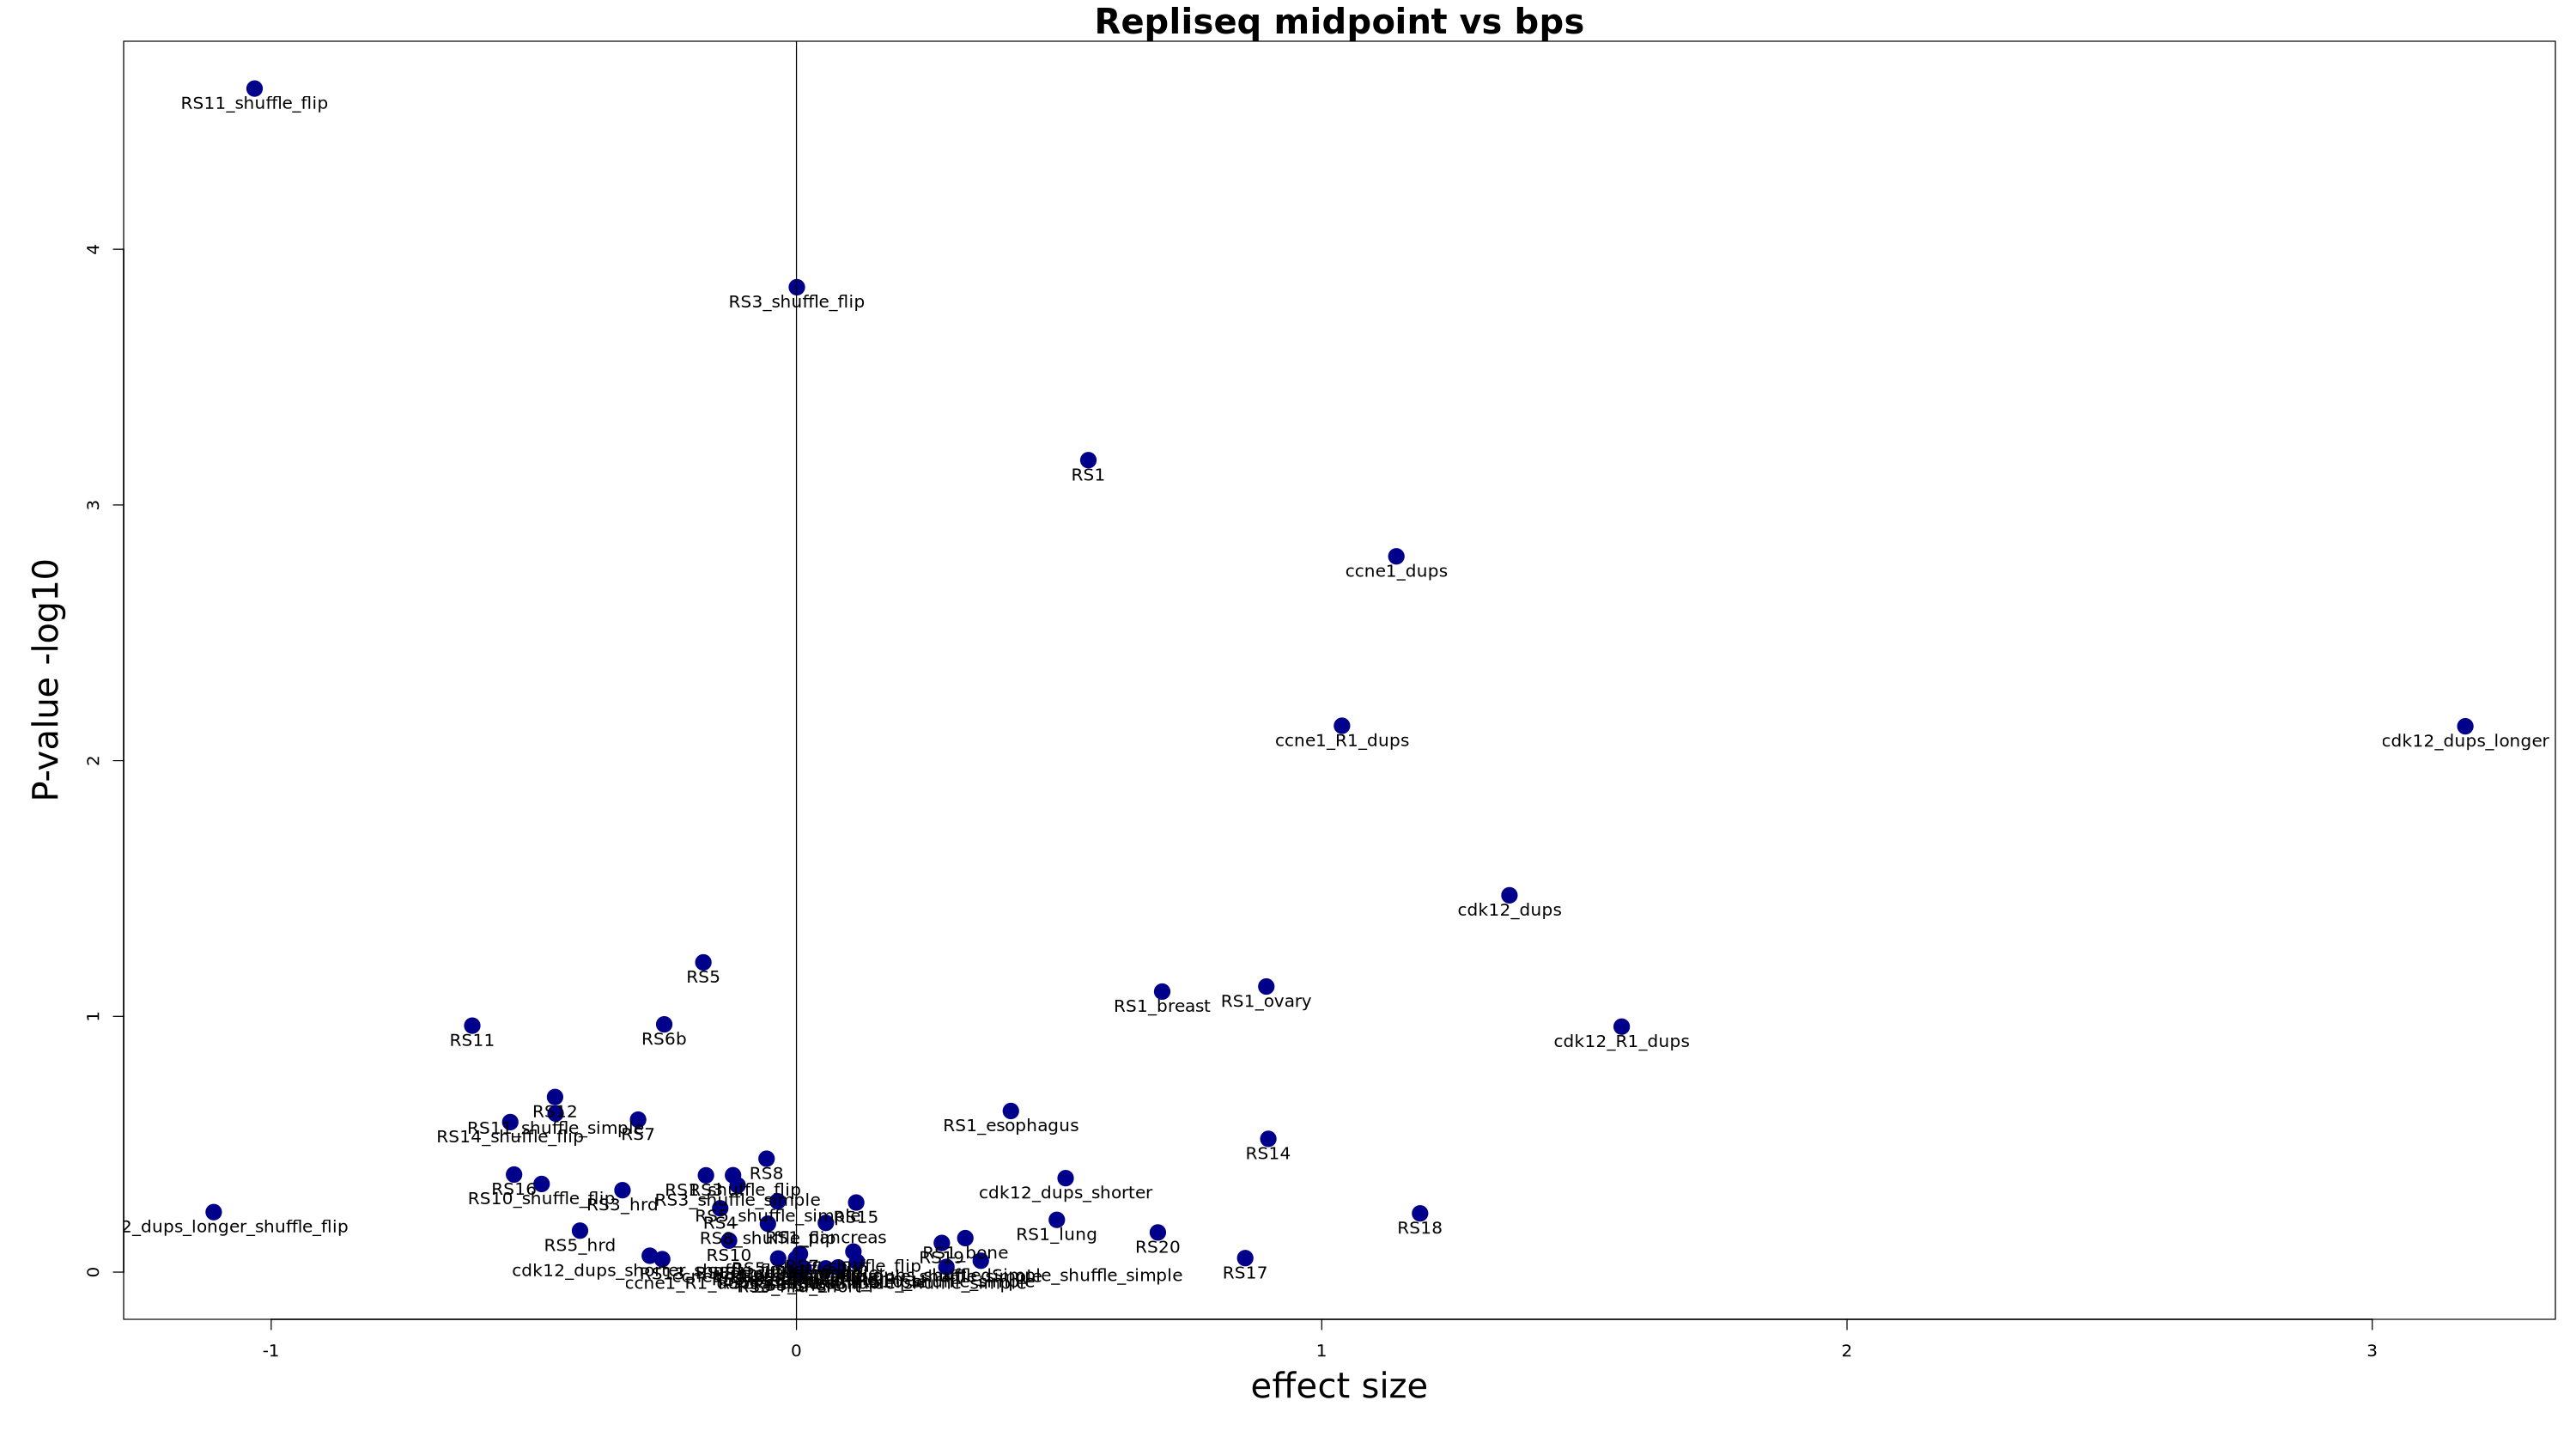

In [15]:
result.df$repliseq_midpoint_both_bp2s_wilcoxonP[result.df$repliseq_midpoint_both_bp2s_wilcoxonP<10^-16] <- 10e-16

options(repr.plot.width=25, repr.plot.height=14)
par( mar = c(6, 6, 2, 1), cex.lab = 2, cex.main = 2)


plot(result.df$repliseq_midpoint_bp2_mean_diff, 
     -log10(as.numeric (result.df$repliseq_midpoint_both_bp2s_wilcoxonP)), pch=19, col='darkblue', cex=2, main='Repliseq midpoint vs bps', xlab='effect size', ylab='P-value -log10')
abline(v=0)
text(result.df$repliseq_midpoint_bp2_mean_diff, 
     -log10(as.numeric(result.df$repliseq_midpoint_both_bp2s_wilcoxonP)),
     label=rownames(result.df), pos=1)


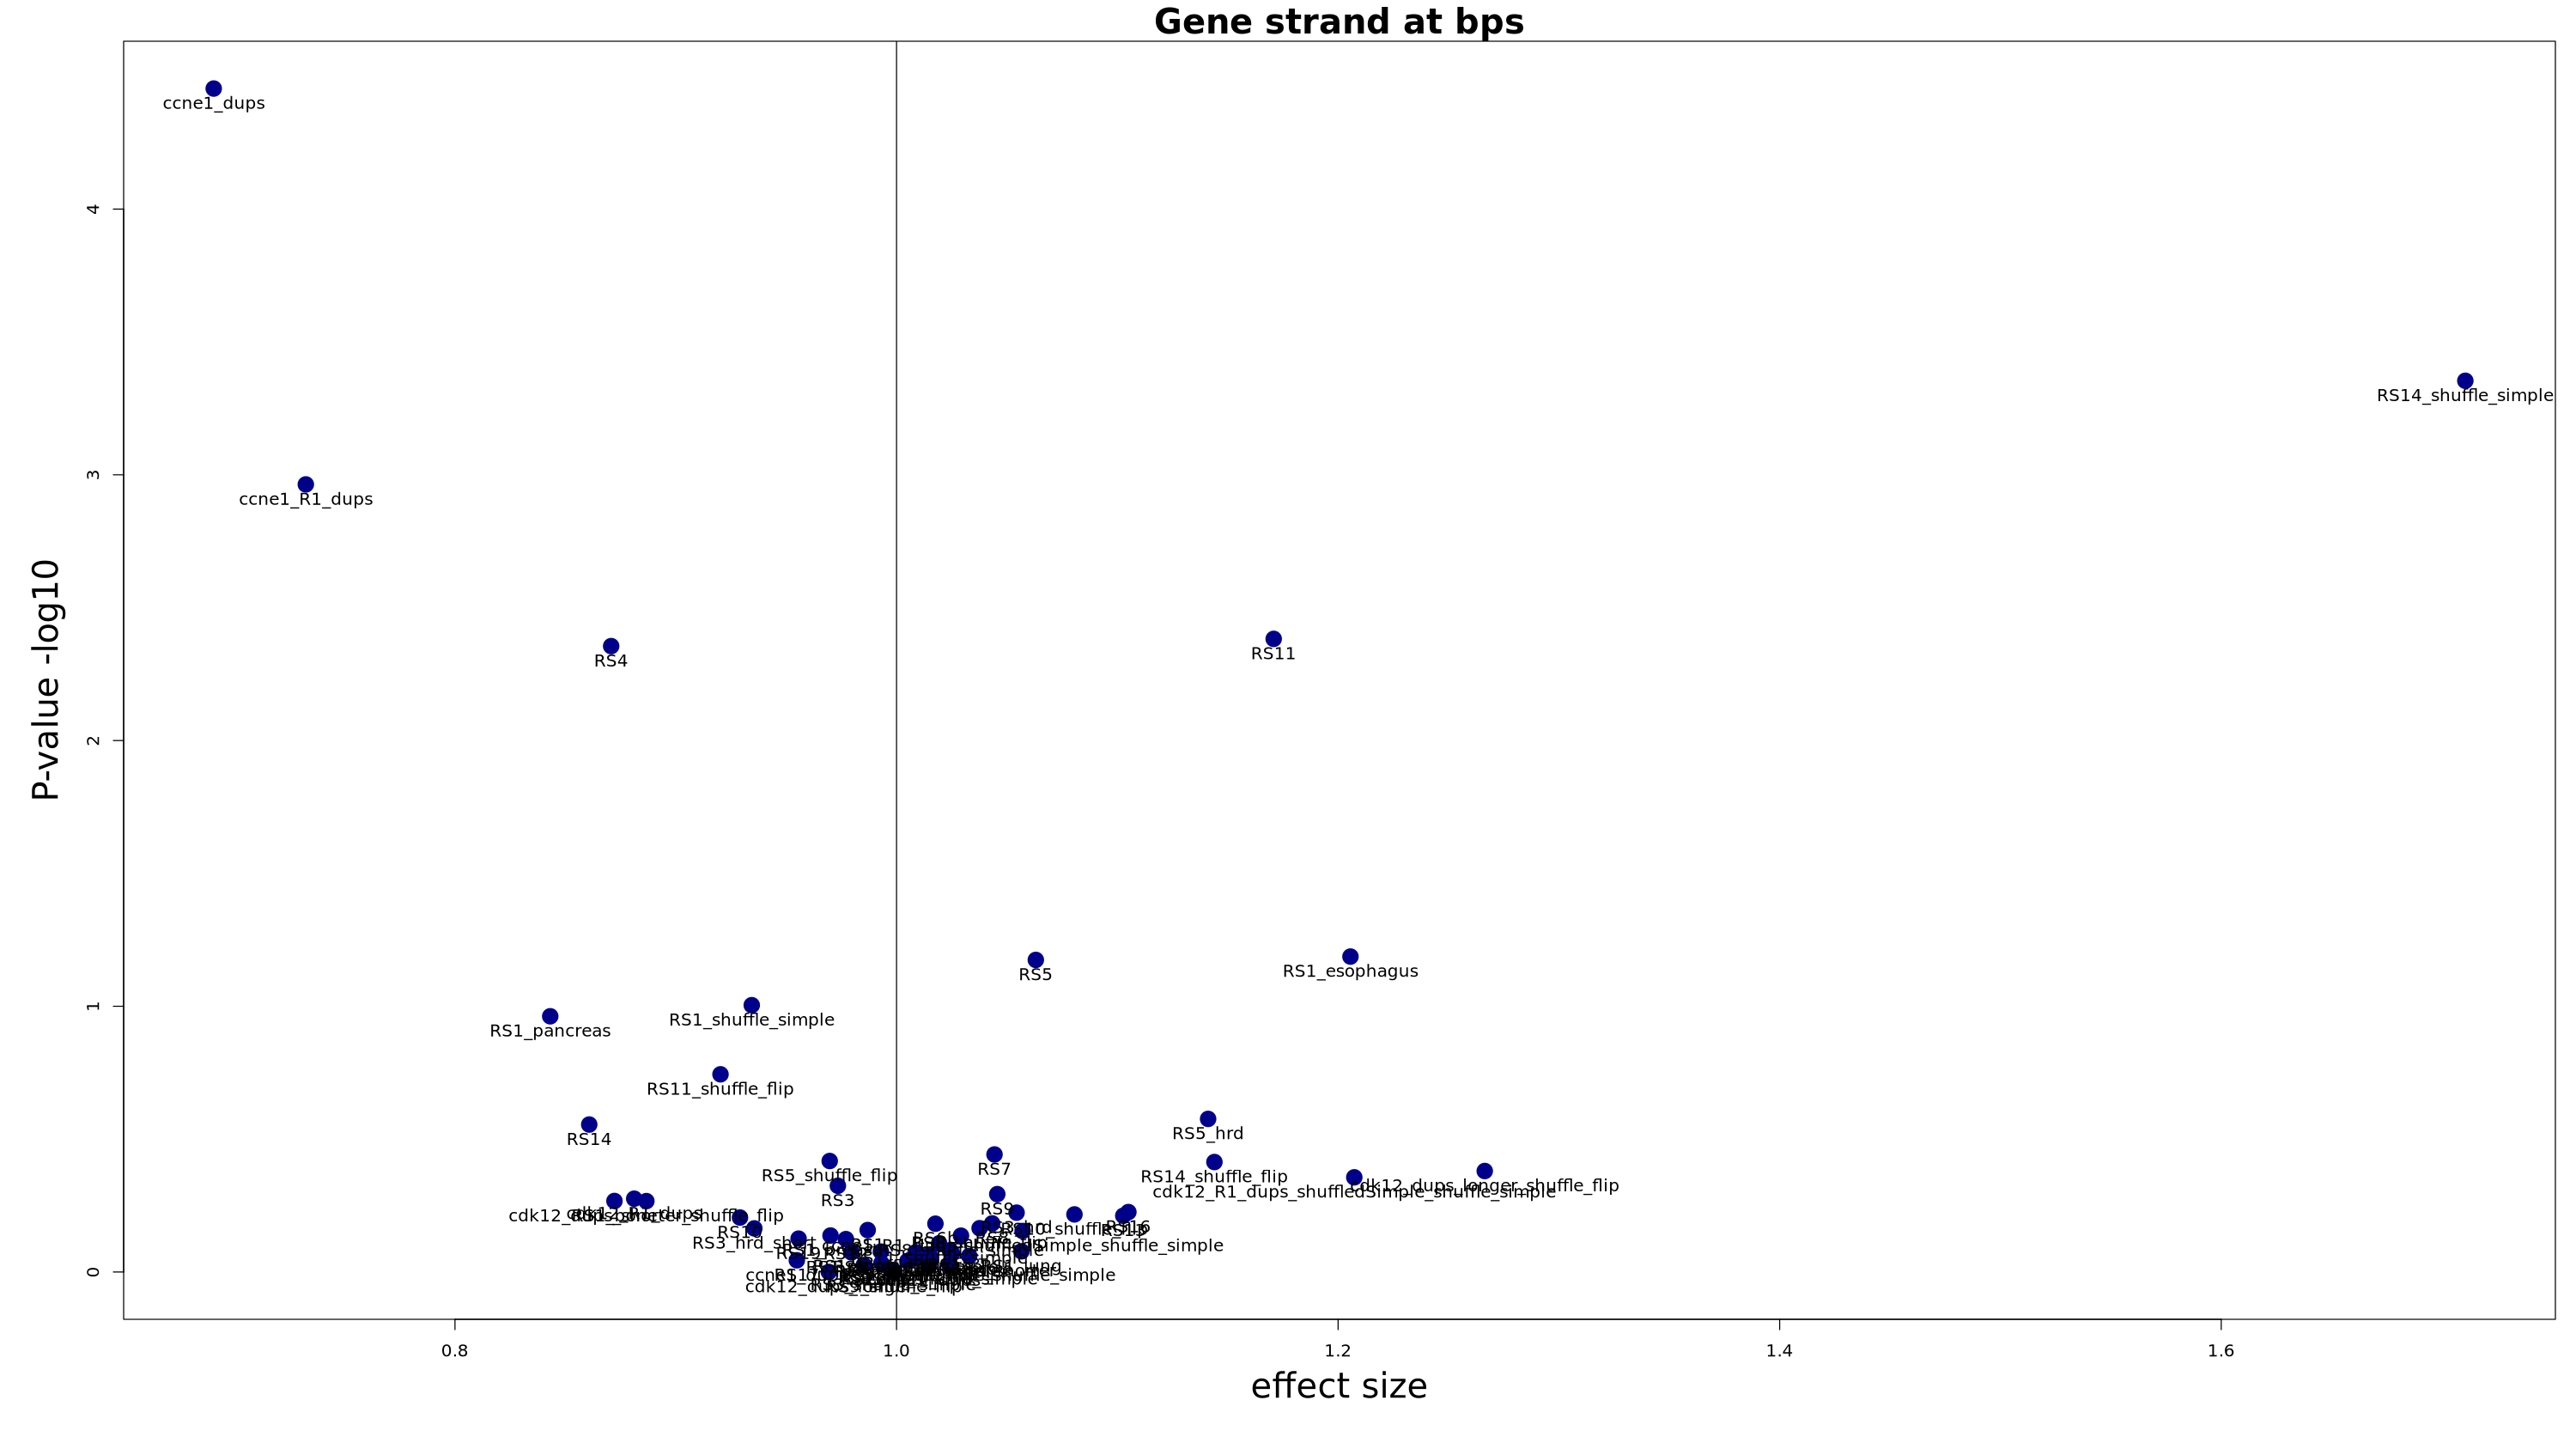

In [16]:
result.df$gene_strand_bp_P[result.df$gene_strand_bp_P<10^-16] <- 10e-16

options(repr.plot.width=25, repr.plot.height=14)
par( mar = c(6, 6, 2, 1), cex.lab = 2, cex.main = 2)


plot(result.df$gene_strand_bp_estimate, 
     -log10(as.numeric (result.df$gene_strand_bp_P)), pch=19, col='darkblue', cex=2, 
     main='Gene strand at bps', xlab='effect size', ylab='P-value -log10')
abline(v=1)
text(result.df$gene_strand_bp_estimate, 
     -log10(as.numeric(result.df$gene_strand_bp_P)),
     label=rownames(result.df), pos=1)

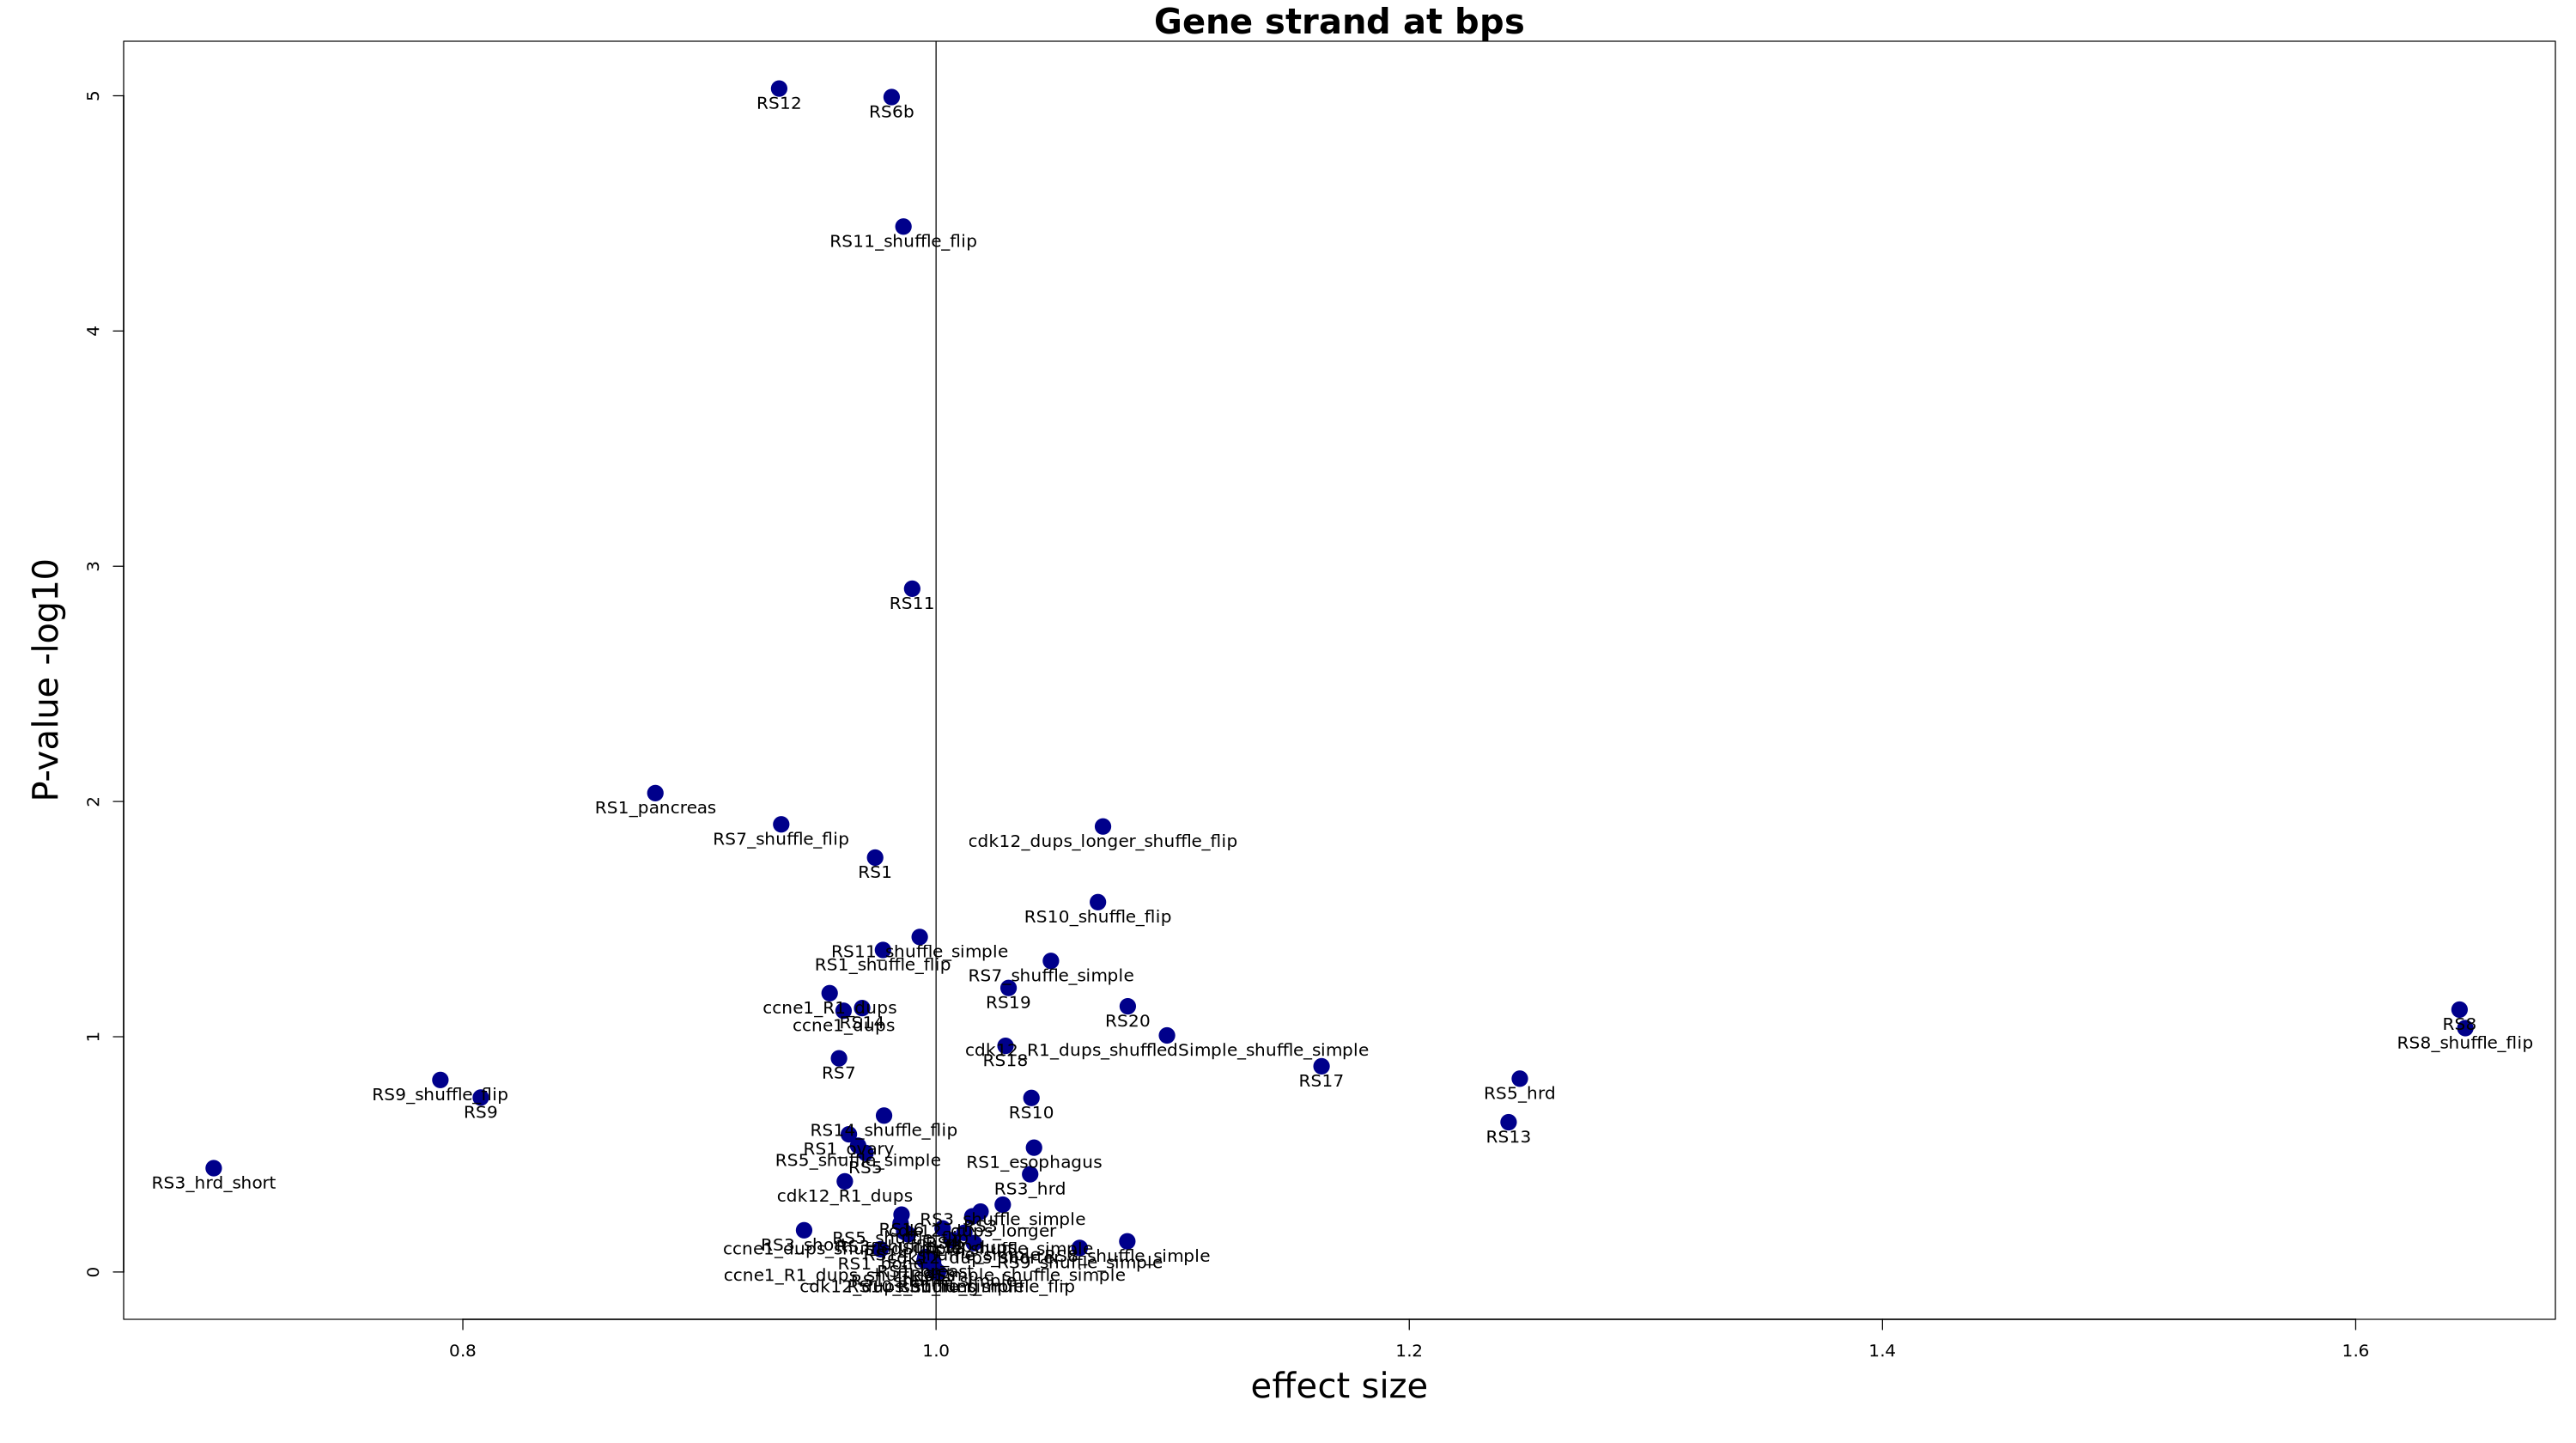

In [17]:
result.df$gene_strand_sv_P[result.df$gene_strand_sv_P<10^-16] <- 10e-16

options(repr.plot.width=25, repr.plot.height=14)
par( mar = c(6, 6, 2, 1), cex.lab = 2, cex.main = 2)


plot(result.df$gene_strand_sv_estimate, 
     -log10(as.numeric (result.df$gene_strand_sv_P)), pch=19, col='darkblue', cex=2, 
     main='Gene strand at bps', xlab='effect size', ylab='P-value -log10')
abline(v=1)
text(result.df$gene_strand_sv_estimate, 
     -log10(as.numeric(result.df$gene_strand_sv_P)),
     label=rownames(result.df), pos=1)